In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as zscore

In [13]:
data = np.array([48,58,52,54,49,51,57,58,55,120,130])

In [14]:
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

In [15]:
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]

In [16]:
print(outliers)

[120 130]


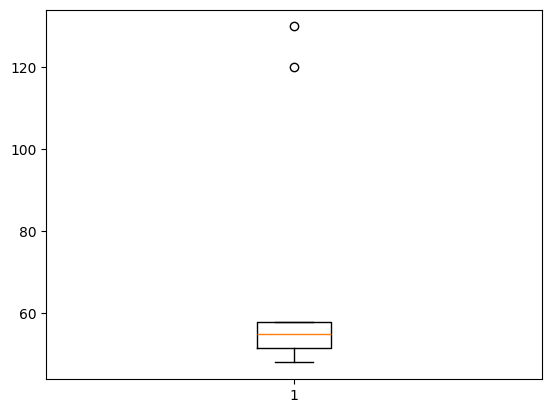

In [17]:
plt.figure()
box = plt.boxplot(data)
plt.show()

In [18]:
z_scores = zscore(data)
outliers_z = data[np.abs(z_scores) > 3]
print(outliers)

TypeError: 'module' object is not callable

In [3]:
df = pd.read_csv(r'C:\Users\suhas\Downloads\people_data.csv')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         45 non-null     float64
 1   name       50 non-null     str    
 2   age        43 non-null     float64
 3   salary     50 non-null     int64  
 4   join_date  50 non-null     str    
 5   city       43 non-null     str    
dtypes: float64(2), int64(1), str(3)
memory usage: 2.5 KB


In [5]:
df.describe()


,id,age,salary
count,45.000000,43.000000,5.000000e+01
mean,25.000000,28.953488,1.067500e+06
std,14.538351,4.191565,1.986629e+06
min,1.000000,22.000000,3.000000e+04
25%,13.000000,25.000000,6.000000e+04
50%,25.000000,28.000000,8.000000e+04
75%,37.000000,30.000000,1.500000e+05
max,49.000000,35.000000,5.000000e+06


In [6]:
df.isnull().sum()

id           5
name         0
age          7
salary       0
join_date    0
city         7
dtype: int64

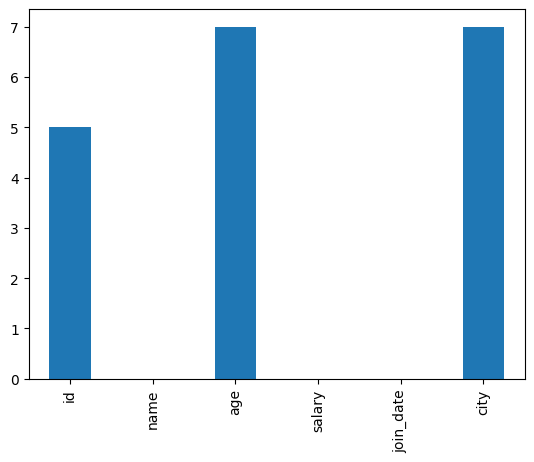

In [8]:
df.isnull().sum().plot(kind='bar')
plt.show()

In [11]:
df['city'] = df['city'].fillna(df['city'].mode()[0])

In [15]:
df['age'] = df['age'].fillna(df['age'].mean())

In [16]:
df['age'].isnull().sum()

np.int64(0)

In [17]:
df

,id,name,age,salary,join_date,city
0,1.0,Arjun,30.000000,60000,2021-07-17,Bangalore
1,2.0,Meena,28.953488,45000,2019-04-11,Delhi
2,3.0,Priya,35.000000,60000,2023-12-02,Delhi
3,4.0,Deepak,35.000000,45000,2018-02-05,Bangalore
4,5.0,Ramesh,28.000000,45000,2017-05-02,Delhi
5,6.0,Suresh,30.000000,150000,2021-08-17,Hyderabad
6,7.0,Pooja,25.000000,150000,2018-05-23,Bangalore
7,8.0,Vikas,35.000000,150000,2024-03-05,Hyderabad
8,9.0,Sneha,22.000000,5000000,2024-04-13,Mumbai
9,NaN,Sunita,25.000000,150000,2016-08-04,Bangalore


In [18]:
df['city'] = df['city'].fillna(df['city'].mode()[0])

In [19]:
df['city'].isnull().sum()

np.int64(0)

<Axes: >

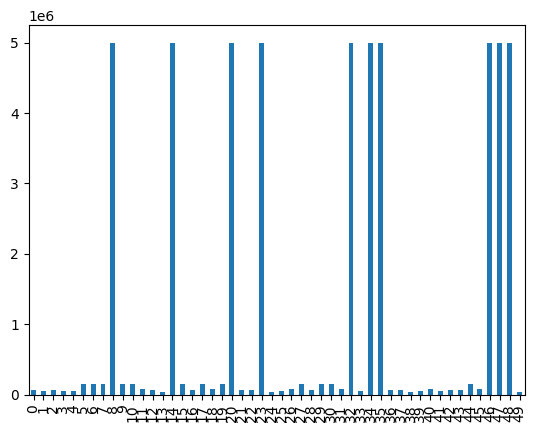

In [23]:
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')  # converting to numeric, coercing errors to NaN
df['salary'].plot(kind='bar')

In [ ]:
df['salary'] = df['salary'].fillna(df['salary'].median())

In [26]:
df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')
df['join_date'] = df['join_date'].fillna(pd.Timestamp.today())